In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([3e2, 3e2, 3e2], dtype=float)




In [2]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

gray = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))


In [3]:
weight=None
filter_type = 'gaussian'
arepo_length = snap.length.uq
filter_length = 10*arepo_length

In [4]:
widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=2048)
extent = slicer.centered_extent.to('Mpc')

Attempting to get derived variable: 0_Volume...	[DONE]



In [5]:

sf = tc.SmoothingFilter(snap, center, widths, npix=128)

In [6]:
smooth_den, turb_den = tc.extract_turbulent_var(snap, sf, '0_Density', 
                                                   filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type)

min/max/avg occupancy cartesian tiling 0 / 21 / 1.82


In [7]:
deriv_dens = tc.extract_derivative_var(snap, sf, '0_Density', filter_length, 
                                     filter_type=filter_type, 
                                     selection=None)

min/max/avg occupancy cartesian tiling 0 / 21 / 1.82


In [12]:
dens_bulk = slicer.slice_variable(smooth_den).to_physical.to('g cm-3')
grad_logrho = slicer.slice_variable(deriv_dens/smooth_den[:,None]).to_physical.to('1 / kpc')

/lustre/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


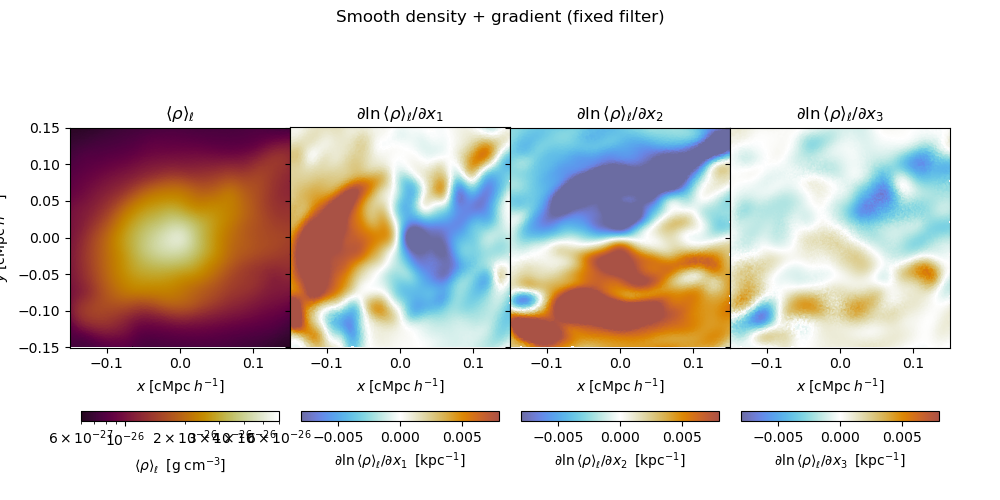

In [15]:

vmin = 6e-27
vmax = 6e-26
norm = LogNorm(vmin=vmin,vmax=vmax)

vmax = 8e-3
vmin = -vmax
norm2 = Normalize(vmin=vmin,vmax=vmax)
# norm2 = SymLogNorm(linthresh=3e-3*vmax, linscale=3.0,
#                         vmin=-8e-1*vmax, vmax=8e-1*vmax, base=10)

cmap = cmr.fall
# cmap2 = cmr.rainforest
cmap2 = cmr.prinsenvlag_r
# cmap2 = cmr.eclipse
# cmap2 = cmr.ghostlight

fig, axes = plt.subplots(1,4, figsize=(10,5),sharex=True, sharey=True)

im00 = axes[0].imshow(
    dens_bulk.value, origin='lower', cmap=cmap, norm=norm, extent=extent.value)

ims_grad = []
for i in range(3):
    imgrad = axes[i+1].imshow(
    grad_logrho[:,:,i].value, origin='lower', cmap=cmap2, norm=norm2, extent=extent.value)

    ims_grad.append(imgrad)
    axes[i+1].set_title(r'$\partial \ln \langle \rho \rangle_\ell / \partial x_%s$'%(i+1))


axes[0].set_title(r'$\langle \rho \rangle_\ell$')

for i in range(4):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))
# axes[1,0].set_ylabel(extent.label('y'))


cbar00 = fig.colorbar(im00, orientation='horizontal',shrink=0.9)
cbar00.set_label(dens_bulk.label('\\langle \\rho \\rangle_\\ell'))

for i in range(3):
    cbar = fig.colorbar(ims_grad[i], orientation='horizontal',shrink=0.9)
    cbar.set_label(grad_logrho[:,:,i].label('\\partial \\ln \\langle \\rho \\rangle_\\ell / \\partial x_%s'%(i+1)))


fig.subplots_adjust(top=0.9,
bottom=0.05,
left=0.07,
right=0.95,
hspace=0.15,
wspace=0.00)

fig.suptitle('Smooth density + gradient (fixed filter)',y=0.98)
# plt.savefig('./gradient_smooth_density.pdf', dpi=400)

# plt.show()